# Genotox unified full pipeline (raw / standardized / preprocessed + grid search + feature analysis)

이 노트북은 아래를 한 번에 수행합니다.
1. raw/base 데이터 적재 및 stage 분석
2. standardized view 생성 및 분석
3. preprocessed feature-ready view 생성 및 분석
4. scaffold split 기반 train/test 구축
5. 작용기/물성/QM/fingerprint feature dataset 생성 및 feature analysis
6. undersampling + grid/randomized hyperparameter search + threshold tuning
7. 모델 평가 및 시각화


In [2]:
from pathlib import Path
import importlib.util, sys

BASE_DIR = Path(r"C:\Users\Administrator\Documents\GitHub\Genotox_model\model")
if not BASE_DIR.exists():
    BASE_DIR = Path('/mnt/data')

SCRIPT_PATH = BASE_DIR / 'genotox_unified_full_pipeline_grid_stageanalysis.py'
OUTPUT_DIR = BASE_DIR / 'runs' / 'unified_full_pipeline_grid_stageanalysis'
ENDPOINTS = ['ames', 'invitro', 'invivo']
SEARCH_METHOD = 'grid'   # 'grid' or 'randomized'
CV_SPLITS = 3
FORCE_REBUILD_FEATURES = True
SAVE_SHAP_BEST_ONLY = True
QM_FILE = None  # 예: BASE_DIR / 'qm_descriptors.csv'
COMPUTE_QM_IF_MISSING = False
FP_BITS = 256
FP_TOP_K_MAP = {'ames': 128, 'invitro': 96, 'invivo': 64}
TUNE_ITER_MAP = {'ames': 16, 'invitro': 12, 'invivo': 10}
BASE_SEED = 42

assert SCRIPT_PATH.exists(), f'스크립트가 없습니다: {SCRIPT_PATH}'
spec = importlib.util.spec_from_file_location('genotox_pipeline', SCRIPT_PATH)
mod = importlib.util.module_from_spec(spec)
sys.modules['genotox_pipeline'] = mod
spec.loader.exec_module(mod)
print('Loaded:', SCRIPT_PATH)
print('Base dir:', BASE_DIR)
print('Output dir:', OUTPUT_DIR)


Loaded: C:\Users\Administrator\Documents\GitHub\Genotox_model\model\genotox_unified_full_pipeline_grid_stageanalysis.py
Base dir: C:\Users\Administrator\Documents\GitHub\Genotox_model\model
Output dir: C:\Users\Administrator\Documents\GitHub\Genotox_model\model\runs\unified_full_pipeline_grid_stageanalysis


C:\Users\Administrator\.conda\envs\genotox\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
summary = mod.run_full_pipeline(
    base_dir=BASE_DIR,
    output_root=OUTPUT_DIR,
    endpoints=ENDPOINTS,
    qm_file=QM_FILE,
    compute_qm_if_missing=COMPUTE_QM_IF_MISSING,
    fp_bits=FP_BITS,
    fp_top_k_map=FP_TOP_K_MAP,
    tune_iter_map=TUNE_ITER_MAP,
    search_method=SEARCH_METHOD,
    cv_splits=CV_SPLITS,
    save_shap_best_only=SAVE_SHAP_BEST_ONLY,
    force_rebuild_features=FORCE_REBUILD_FEATURES,
    base_seed=BASE_SEED,
)
summary


C:\Users\Administrator\Documents\GitHub\Genotox_model\model\genotox_unified_full_pipeline_grid_stageanalysis.py:408: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  analysis["No_norm"] = normalize_no_series(analysis["No"])
[16:53:24] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4
[16:53:24] Explicit valence for atom # 7 P, 7, is greater than permitted
[16:53:24] Can't kekulize mol.  Unkekulized atoms: 3 4 5 6 7
[16:53:24] Explicit valence for atom # 1 P, 7, is greater than permitted
[16:53:24] Can't kekulize mol.  Unkekulized atoms: 3 6 7
[16:53:24] Can't kekulize mol.  Unkekulized atoms: 1 2 13
[16:53:24] Can't kekulize mol.  Unkekulized atoms: 1 2 12
[16:53:24] Can't kekulize mol.  Unkekulized atoms: 1 2 12
[16:53:24] Can't kekulize mol.  Unkekulized ato

,tn,fp,fn,tp,sensitivity,specificity,balanced_accuracy,mcc,roc_auc,pr_auc,...,sampling_strategy,model_name,feature_blocks,n_features,train_n,test_n,selected_train_n,selected_train_pos_rate,test_pos_rate,search_method
0,1641,265,147,690,0.824373,0.860965,0.842669,0.662436,0.912696,0.842951,...,none,xgb,"physchem,rules,fg_present,fg_count,fingerprint...",452,10971,2743,10971,0.305077,0.305140,grid
1,226,35,27,6,0.181818,0.865900,0.523859,0.043482,0.722629,0.225371,...,coverage_hardneg,xgb,"physchem,rules,fg_present,fg_count,fingerprint...",419,1172,294,328,0.399390,0.112245,grid
2,299,74,10,4,0.285714,0.801609,0.543661,0.040646,0.651953,0.056044,...,coverage_hardneg,xgb,"physchem,rules,fg_present,fg_count,fingerprint...",385,1548,387,171,0.333333,0.036176,grid


C:\Users\Administrator\Documents\GitHub\Genotox_model\model\runs\unified_full_pipeline_grid_stageanalysis\_summary\summary_metrics.csv
C:\Users\Administrator\Documents\GitHub\Genotox_model\model\runs\unified_full_pipeline_grid_stageanalysis\_summary\stage_profile_comparison.csv


,tn,fp,fn,tp,sensitivity,specificity,balanced_accuracy,mcc,roc_auc,pr_auc,...,sampling_strategy,model_name,feature_blocks,n_features,train_n,test_n,selected_train_n,selected_train_pos_rate,test_pos_rate,search_method
0,1641,265,147,690,0.824373,0.860965,0.842669,0.662436,0.912696,0.842951,...,none,xgb,"physchem,rules,fg_present,fg_count,fingerprint...",452,10971,2743,10971,0.305077,0.305140,grid
1,226,35,27,6,0.181818,0.865900,0.523859,0.043482,0.722629,0.225371,...,coverage_hardneg,xgb,"physchem,rules,fg_present,fg_count,fingerprint...",419,1172,294,328,0.399390,0.112245,grid
2,299,74,10,4,0.285714,0.801609,0.543661,0.040646,0.651953,0.056044,...,coverage_hardneg,xgb,"physchem,rules,fg_present,fg_count,fingerprint...",385,1548,387,171,0.333333,0.036176,grid


,endpoint,stage,n_rows,n_cols,n_missing_cells,fraction_missing_cells,positive_rate,n_unique_No,n_unique_SMILES,n_unique_canonical_smiles,n_unique_standardized_smiles
0,ames,raw,13714,6,0,0.000000,0.305090,13714,12769,NaN,NaN
1,ames,standardized,13714,12,18,0.000109,0.305090,13714,12769,12760.0,12684.0
2,ames,preprocessed,13714,306,6188,0.001475,0.305090,13714,12769,12760.0,12684.0
3,invitro,raw,1466,5,0,0.000000,0.111869,1466,1466,NaN,NaN
4,invitro,standardized,1466,10,2,0.000136,0.111869,1466,1466,1465.0,1455.0
5,invitro,preprocessed,1466,303,899,0.002024,0.111869,1466,1466,1465.0,1455.0
6,invivo,raw,1935,6,0,0.000000,0.036693,1935,1935,NaN,NaN
7,invivo,standardized,1935,12,6,0.000258,0.036693,1935,1935,1932.0,1896.0
8,invivo,preprocessed,1935,303,1666,0.002842,0.036693,1935,1935,1932.0,1896.0


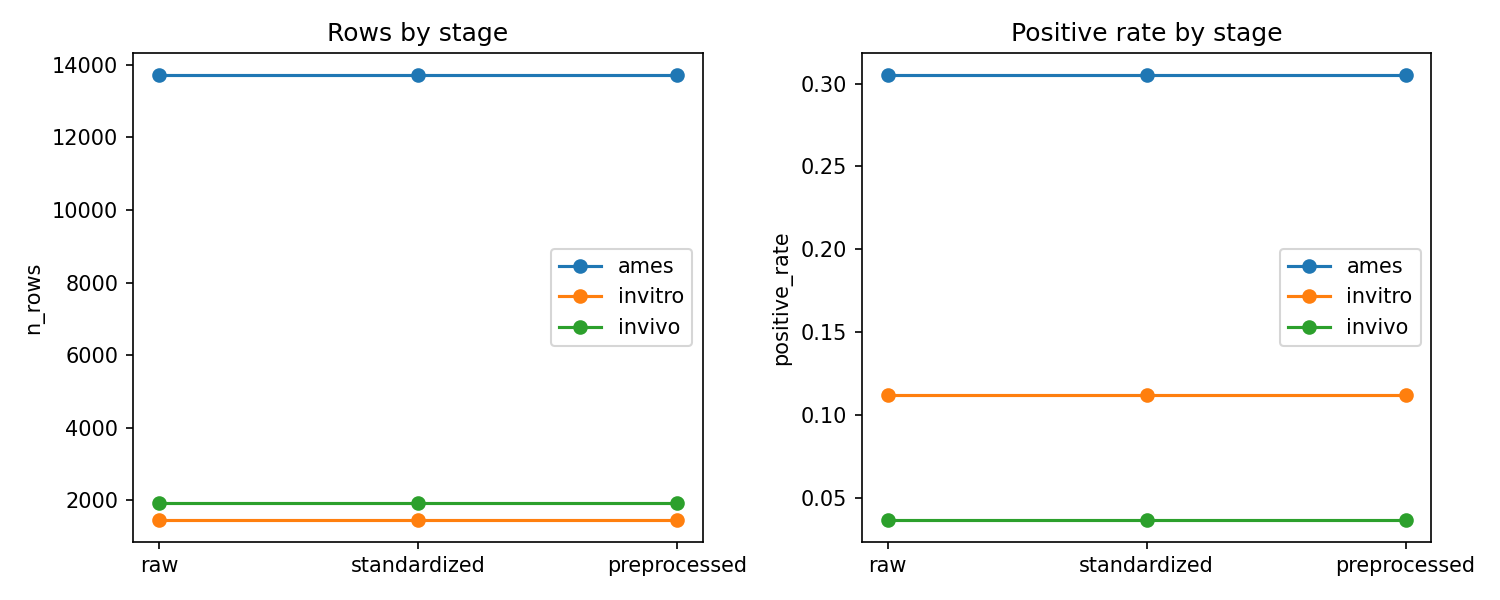

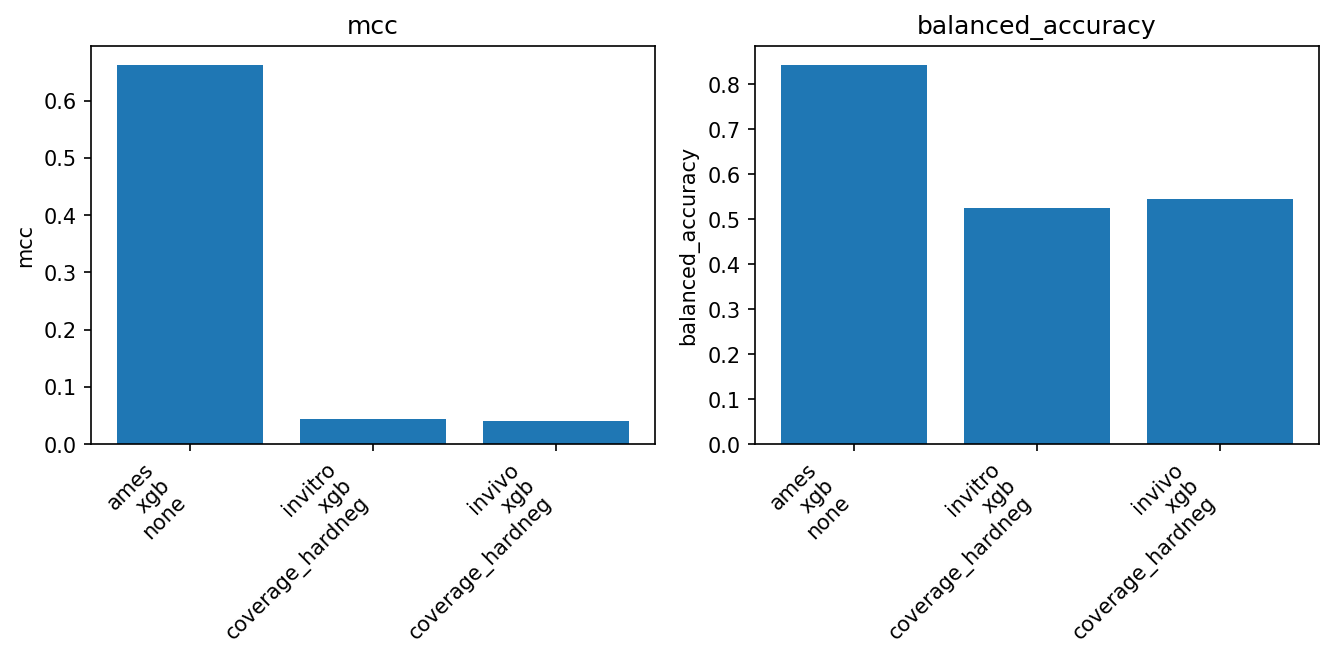

In [4]:
from IPython.display import display, Image
summary_path = OUTPUT_DIR / '_summary' / 'summary_metrics.csv'
stage_comp_path = OUTPUT_DIR / '_summary' / 'stage_profile_comparison.csv'
stage_fig = OUTPUT_DIR / '_summary' / 'stage_profile_comparison.png'
dashboard_fig = OUTPUT_DIR / '_summary' / 'summary_dashboard.png'
print(summary_path)
print(stage_comp_path)
display(summary.sort_values(['endpoint','mcc'], ascending=[True, False]))
if stage_comp_path.exists():
    display(mod.pd.read_csv(stage_comp_path))
if stage_fig.exists():
    display(Image(filename=str(stage_fig)))
if dashboard_fig.exists():
    display(Image(filename=str(dashboard_fig)))


In [5]:
# 예시: endpoint별 stage/feature analysis 파일 확인
for ep in ENDPOINTS:
    print('\n===', ep, '===')
    print('raw profile:', OUTPUT_DIR / ep / '01_raw' / 'raw_profile_summary.csv')
    print('standardized profile:', OUTPUT_DIR / ep / '02_standardized' / 'standardized_profile_summary.csv')
    print('preprocessed profile:', OUTPUT_DIR / ep / '03_preprocessed' / 'preprocessed_profile_summary.csv')
    print('feature block manifest:', OUTPUT_DIR / ep / '05_features' / 'feature_block_manifest.csv')
    print('top numeric association:', OUTPUT_DIR / ep / '05_features' / 'top_numeric_association.csv')
    print('binary feature lift:', OUTPUT_DIR / ep / '05_features' / 'binary_feature_lift.csv')



=== ames ===
raw profile: C:\Users\Administrator\Documents\GitHub\Genotox_model\model\runs\unified_full_pipeline_grid_stageanalysis\ames\01_raw\raw_profile_summary.csv
standardized profile: C:\Users\Administrator\Documents\GitHub\Genotox_model\model\runs\unified_full_pipeline_grid_stageanalysis\ames\02_standardized\standardized_profile_summary.csv
preprocessed profile: C:\Users\Administrator\Documents\GitHub\Genotox_model\model\runs\unified_full_pipeline_grid_stageanalysis\ames\03_preprocessed\preprocessed_profile_summary.csv
feature block manifest: C:\Users\Administrator\Documents\GitHub\Genotox_model\model\runs\unified_full_pipeline_grid_stageanalysis\ames\05_features\feature_block_manifest.csv
top numeric association: C:\Users\Administrator\Documents\GitHub\Genotox_model\model\runs\unified_full_pipeline_grid_stageanalysis\ames\05_features\top_numeric_association.csv
binary feature lift: C:\Users\Administrator\Documents\GitHub\Genotox_model\model\runs\unified_full_pipeline_grid_stag